 Step:-1 INITIAL SHAPE & TYPE ANALYSIS
Total Rows Ingested: 6000 | Total Column: 6

--- Structural Null Counts---
Employee_ID            0
Job_Title            274
Department           261
Years_Experience     462
Performance_Tier       0
Annual_Salary_USD    274
dtype: int64

Step-2 POST-SANTIZATION NULL COUNTS

Employee_ID            0
Job_Title              0
Department             0
Years_Experience     405
Performance_Tier     297
Annual_Salary_USD      0
dtype: int64

 Step:3 Cleaned Transformation Metrics

       Years_Experience  Annual_Salary_USD  Performance_Rank
count       4814.000000        4814.000000       4814.000000
mean           8.062734      105588.288975          1.994391
std            9.337821       46388.127389          0.717657
min            1.000000       25008.744034          1.000000
25%            3.000000       64848.232269          1.000000
50%            5.000000      105905.802072          2.000000
75%            8.000000      146074.436179          3.

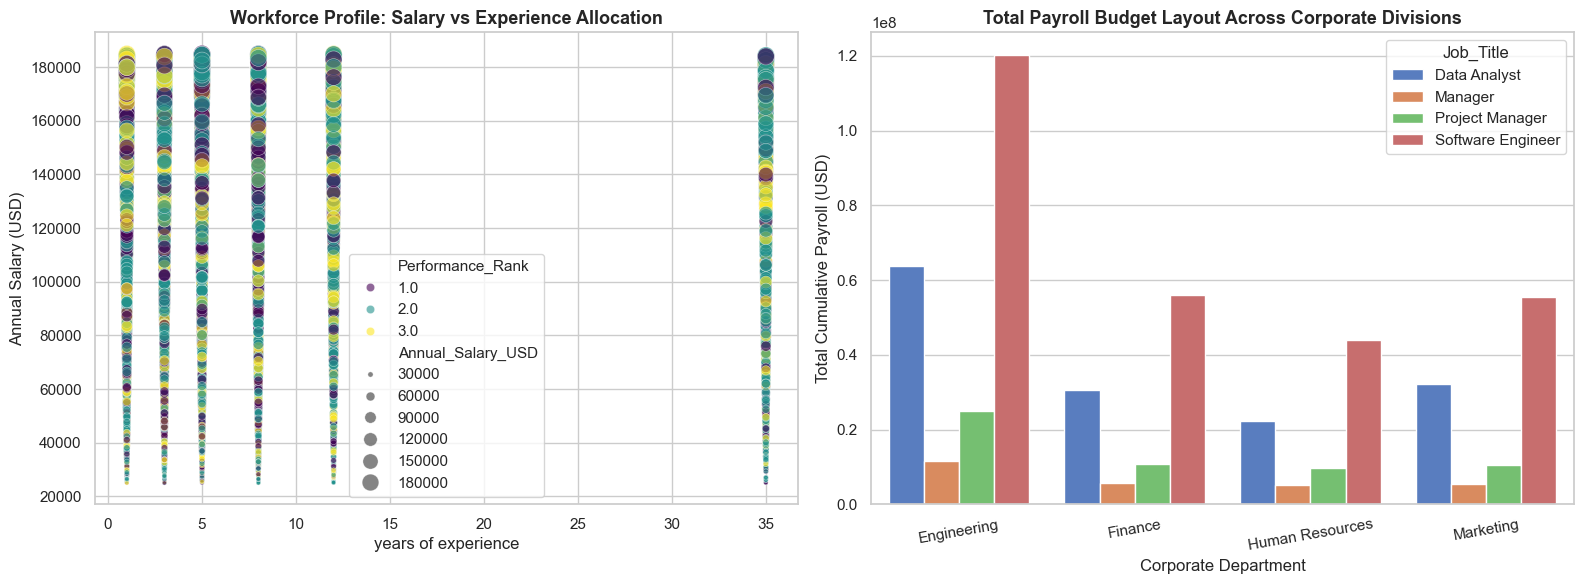

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#==================================================================
# 1. INDEPENDENT FILE INGESTION & STRUCTURAL METADATA AUDIT
#==================================================================

df = pd.read_csv('raw_employee_records.csv')
print(" Step:-1 INITIAL SHAPE & TYPE ANALYSIS")
print(f"Total Rows Ingested: {df.shape[0]} | Total Column: {df.shape[1]}")
print("\n--- Structural Null Counts---")
print(df.isnull().sum())

# ================================================================
# 2. STRING SANITIZATION & LOGICAL PLACEHOLDER REPLACEMENT
# ================================================================

# Problem: 'Job_title' has mixed casing (lower, upper, mixed) and leading/trailing spaces
# Action: Strip spaces and convert everything to clean Title Case Text
df['Job_Title'] = df['Job_Title'].str.strip().str.title()

# Map corrupt text setting to clean , system-recognozed NumPy NaN markers
corrupt_text_flags = {'Unknown':np.nan, 'N/A': np.nan, 'Missing': np.nan, 'UNKNOWN': np.nan, 'MISSING': np.nan} 
df['Job_Title']= df['Job_Title'].replace(corrupt_text_flags)
df['Department'] = df['Department'].replace(corrupt_text_flags)
df['Performance_Tier'] = df['Performance_Tier'].replace(corrupt_text_flags)


# High Priority Resize Action: Drop rows missing the primary label 'Job_Title'
df = df.dropna(subset=['Job_Title'])

# Impute missing 'Department' values with the Mode (The Most common department)
hospital_dept_mode = df['Department'].mode()[0]
df['Department']= df['Department'].fillna(hospital_dept_mode)

print( "\nStep-2 POST-SANTIZATION NULL COUNTS\n")
print(df.isnull().sum())

# ================================================================
# 3. NUMERICAL RANGE FILTERING & ORDINAL SCALE MAPPING
# ================================================================

# Problem: Negative Experience values are impossible; 99 is an obvious system typing glitch
# Action: Implement a logical mask to filter data inside realstic boundaries (0 to 45 years)

valid_experience_mask = (df['Years_Experience'] >= 0) & (df['Years_Experience'] <= 45)
df = df[valid_experience_mask]

# Convert categorical string 'Perfomance_Tier' down to a clean orderd rank integer
ordinal_rank_map = {'Level-1 (Low)':1, 'Level-2 (Medium)':2,'Level-3 (High)':3}
df['Performance_Rank'] = df['Performance_Tier'].map(ordinal_rank_map)

# Fill any empty performance slots with the median rank value
df['Performance_Rank']= df['Performance_Rank'].fillna(df['Performance_Rank'].median())

print("\n Step:3 Cleaned Transformation Metrics\n")
print(df[['Years_Experience','Annual_Salary_USD','Performance_Rank']].describe())

# ================================================================
# 4. INDUSTRIAL GROUPING, ANALYSIS & INTERMEDIATE CSV STORAGE
# ================================================================

# TAsk: Calculate workforce distribution , average experience, and total payroll expenses
payroll_summary_report = df.groupby(['Department','Job_Title']).agg(
    Total_Employees = ('Employee_ID','count'),
    Avg_Years_experience = ('Years_Experience', 'mean'),
    Total_Payroll_Budget_USD = ('Annual_Salary_USD','sum'),
    Average_Salary_USD = ('Annual_Salary_USD','mean')
).reset_index()

# Export the processed intermediate summary table to a separate file
payroll_summary_report.to_csv('cleaned_payroll_summary.csv', index=False)
print("💾 Success! Intermediate aggregation file exported as 'cleaned_payroll_summary.csv'.\n")

# ================================================================
# 5. DATA VISUALIZATION ENGINE
# ================================================================

sns.set_theme(style= 'whitegrid')
fig,axes = plt.subplots(1,2, figsize = (16,6))

# Visualization Plot A: Scatter distribution tracking Salary vs Experience split by performance
sns.scatterplot(
    x= 'Years_Experience',
    y= 'Annual_Salary_USD',
    hue= 'Performance_Rank',
    size = 'Annual_Salary_USD',
    sizes = (10,150),
    data =df,
    palette = "viridis",
    ax =axes[0],
    alpha =0.6
)

axes[0].set_title('Workforce Profile: Salary vs Experience Allocation', fontweight='bold', fontsize=13)
axes[0]. set_xlabel('years of experience')
axes[0].set_ylabel('Annual Salary (USD)')

# Visualization Plot B: Structured Bar Chart visualizing payroll budget density per department
sns.barplot(
    x='Department', 
    y='Total_Payroll_Budget_USD', 
    hue='Job_Title', 
    data=payroll_summary_report, 
    palette='muted', 
    ax=axes[1]
)
axes[1].set_title('Total Payroll Budget Layout Across Corporate Divisions', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Corporate Department')
axes[1].set_ylabel('Total Cumulative Payroll (USD)')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()